# Disaster effects prediction and insight with NSF

**steps**:
- load the disaster dataset and feats dataset
- combine them
- make a dataset for each disaster type
- for each type (starting with only one):
    * standardize and normalize the features
    * define the NSF model
    * train the model
    * inspect the resulting distribution
    * see the conditioning features effects

**dataset design**:
- one dataframe per event type
- time reference feat as ...
- no topographical feat as coords, not state/county
- geographical and natural feats for conditioning
- casualties and damages as y 

#### imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import matplotlib.colors as mcolors

import seaborn as sns
from pathlib import Path
from scipy.stats import gaussian_kde
from scipy import stats
import time

import torch
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import zuko

import utils
import ipynbname

In [ ]:
DATASET_PATH = Path("../../datasets/disasters_merged_all_feats.csv")
EVENT_GROUP = 'All'
RUN_PATH = Path(f"../../runs/flow_all.pt")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Data Preparation

In [ ]:
df = pd.read_csv(DATASET_PATH)

### Group by event type

In [ ]:
df['EVENT_GROUP'].value_counts()

EVENT_GROUP
Wind           152966
Hail            57980
Storm           55795
Flood           49691
Freeze          39347
Drought         20115
Snow            19792
Heat            14279
Heavy Rain      10488
Fog              4943
Wildfire         2505
Lightning        2261
Debris Flow      1047
Avalanche         203
Name: count, dtype: int64

In [ ]:
event_group_dfs = {
    'Wind': df[df['EVENT_GROUP'] == 'Wind'],#.drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Storm': df[df['EVENT_GROUP'] == 'Storm'],#.drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Flood': df[df['EVENT_GROUP'] == 'Flood'],#.drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Freeze': df[df['EVENT_GROUP'] == 'Freeze'],#.drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Drought': df[df['EVENT_GROUP'] == 'Drought'],#.drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Snow': df[df['EVENT_GROUP'] == 'Snow'],#.drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Heat': df[df['EVENT_GROUP'] == 'Heat'],#.drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Heavy Rain': df[df['EVENT_GROUP'] == 'Heavy Rain'],#.drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Fog': df[df['EVENT_GROUP'] == 'Fog'],#.drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Wildfire': df[df['EVENT_GROUP'] == 'Wildfire'],#.drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Lightning': df[df['EVENT_GROUP'] == 'Lightning'],#.drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Debris Flow': df[df['EVENT_GROUP'] == 'Debris Flow'],#.drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Avalanche': df[df['EVENT_GROUP'] == 'Avalanche'],#.drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
}

### Sample dataset

In [ ]:
# build a single dataset sampling 100000 total points from the event groups, balancing the class distribution when possible
sampled_dfs = []
for group, df in event_group_dfs.items():
    n_samples = min(len(df), 100000 // len(event_group_dfs))
    sampled_df = df.sample(n=n_samples, random_state=42)
    sampled_dfs.append(sampled_df)

df = pd.concat(sampled_dfs, ignore_index=True)

In [ ]:
df['EVENT_GROUP'].value_counts()

EVENT_GROUP
Wind           7692
Storm          7692
Flood          7692
Freeze         7692
Drought        7692
Snow           7692
Heat           7692
Heavy Rain     7692
Fog            4943
Wildfire       2505
Lightning      2261
Debris Flow    1047
Avalanche       203
Name: count, dtype: int64

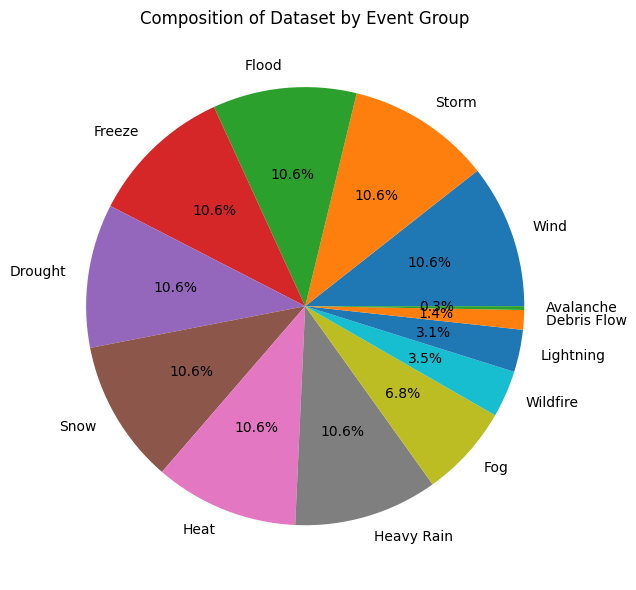

In [ ]:
plt.figure(figsize=(10, 6))
df['EVENT_GROUP'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Composition of Dataset by Event Group')
plt.ylabel('')
plt.tight_layout()
plt.show()

### Data normalization

In [ ]:
TARGET_COLS = ["DAMAGES", "CASUALTIES"]

X_COLS = [
    'BEGIN_LAT', 'BEGIN_LON',
    'DURATION_HOURS', 'WIND_SPEED', # change with hail size for hail
    'TIME_DAY_SIN', 'TIME_DAY_COS', 'TIME_YEAR_NORM',
    'PRECIPITATION', 'TMIN', 'TMAX',
    'ELEVATION', 'SLOPE',
    'COV_BARREN', 'COV_CULTIVATED', 'COV_VEGETATION',
    'COV_FOREST', 'COV_WATER', 'COV_SNOW_ICE', 'COV_URBAN',
    'RIVER_DISTANCE', 'SEA_DISTANCE',
]

In [ ]:
X = df[X_COLS].values.astype(np.float32)
Y = df[TARGET_COLS].values.astype(np.float32)

In [ ]:
# targets log transformation
Y = np.log1p(Y)

In [ ]:
# train-val-test split
X_train, X_temp, Y_train, Y_temp = train_test_split(X, Y, test_size=0.3, random_state=42)

X_val, X_test, Y_val, Y_test = train_test_split(X_temp, Y_temp, test_size=0.5, random_state=42)

In [ ]:
# standardize features and targets
x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train = x_scaler.fit_transform(X_train)
X_val   = x_scaler.transform(X_val)
X_test  = x_scaler.transform(X_test)

Y_train = y_scaler.fit_transform(Y_train)
Y_val   = y_scaler.transform(Y_val)
Y_test  = y_scaler.transform(Y_test)


### Dataset split

In [ ]:
# conversion to tensors and move to device
X_train = torch.tensor(X_train).to(device)
Y_train = torch.tensor(Y_train).to(device)

X_val = torch.tensor(X_val).to(device)
Y_val = torch.tensor(Y_val).to(device)

X_test = torch.tensor(X_test).to(device)
Y_test = torch.tensor(Y_test).to(device)


In [ ]:
# data loaders
train_ds = TensorDataset(X_train, Y_train)
val_ds   = TensorDataset(X_val, Y_val)
test_ds   = TensorDataset(X_val, Y_val)

## Model

### Model definition

In [ ]:
EPOCHS = 200
LEARNING_RATE = 1e-3
BATCH_SIZE = 256

In [ ]:
X_DIM = X_train.shape[1]
Y_DIM = 2   # DAMAGES, CASUALTIES

flow = zuko.flows.NSF(
    features=Y_DIM,
    context=X_DIM,
    transforms=8,
    hidden_features=[256, 256, 256],
    bins=16
)

In [ ]:
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE)
test_loader   = DataLoader(test_ds, batch_size=BATCH_SIZE)

In [ ]:
print(f"NSF model created with {sum(p.numel() for p in flow.parameters())} parameters")

NSF model created with 1295088 parameters


### Model Loading

In [ ]:
flow.load_state_dict(torch.load(RUN_PATH))
flow.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
flow = flow.to(device)

C:\Users\matti\AppData\Local\Temp\ipykernel_12084\4212689827.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  flow.load_state_dict(torch.load(RUN_PATH))


### Model Evaluation

In [ ]:
def sample_predictive(flow, x, n=10000):
    """
    x: torch tensor shape (1, X_DIM)
    returns samples in original scale: (n,2)
    """
    with torch.no_grad():
        dist = flow(x)
        samples = dist.sample((n,)).squeeze(1).cpu().numpy()

    samples = y_scaler.inverse_transform(samples)
    samples = np.expm1(samples)
    return samples


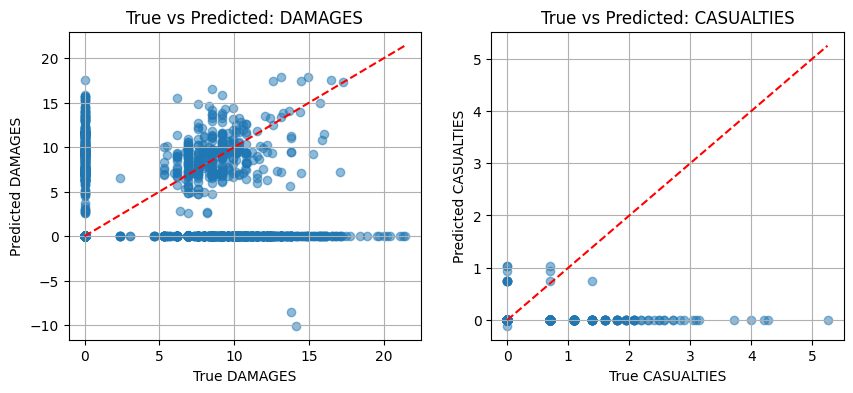

In [ ]:
# Run inference for the test set and plot results for damages and casualties
def run_inference_and_plot(flow, test_loader, y_scaler, target_cols):
    flow.eval()
    y_true = []
    y_pred = []
    with torch.no_grad():
        for x_batch, y_batch in test_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
            # Get the distribution and sample from it
            dist = flow(x_batch)
            y_hat = dist.sample().squeeze(1)  # shape: [batch, 2]
            y_true.append(y_batch.cpu())
            y_pred.append(y_hat.cpu())
    y_true = torch.cat(y_true, dim=0).numpy()
    y_pred = torch.cat(y_pred, dim=0).numpy()
    # Inverse scale
    y_true = y_scaler.inverse_transform(y_true)
    y_pred = y_scaler.inverse_transform(y_pred)
    # Plot for each target
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.scatter(y_true[:, 0], y_pred[:, 0], alpha=0.5)
    plt.xlabel(f"True {target_cols[0]}")
    plt.ylabel(f"Predicted {target_cols[0]}")
    plt.title(f"True vs Predicted: {target_cols[0]}")
    plt.plot([y_true[:, 0].min(), y_true[:, 0].max()], [y_true[:, 0].min(), y_true[:, 0].max()], 'r--')
    plt.grid()
    plt.subplot(1,2,2)
    plt.scatter(y_true[:, 1], y_pred[:, 1], alpha=0.5)
    plt.xlabel(f"True {target_cols[1]}")
    plt.ylabel(f"Predicted {target_cols[1]}")
    plt.title(f"True vs Predicted: {target_cols[1]}")
    plt.plot([y_true[:, 1].min(), y_true[:, 1].max()], [y_true[:, 1].min(), y_true[:, 1].max()], 'r--')
    plt.grid()
    plt.show()

run_inference_and_plot(flow, test_loader, y_scaler, TARGET_COLS)

In [ ]:
def run_inference_and_plot_mc(flow, test_loader, y_scaler, target_cols, n_samples=3):
    """Run Monte Carlo inference by sampling multiple times from the conditional distribution.
    
    For each (x, y) in the test set:
    - Sample n_samples times from p(y|x)
    - Compute mean and std of samples
    - Compare mean prediction to true y
    """
    flow.eval()
    y_true_all = []
    y_mean_all = []
    y_std_all = []
    
    with torch.no_grad():
        for x_batch, y_batch in test_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
            B = x_batch.shape[0]
            
            # Get the conditional distribution
            dist = flow(x_batch)
            
            # Sample multiple times: [n_samples, B, 2]
            samples = torch.stack([dist.sample().squeeze(1) for _ in range(n_samples)], dim=0)
            
            # Move to CPU and convert to numpy: [n_samples, B, 2]
            samples_np = samples.cpu().numpy()
            
            # Inverse scale all samples
            n_s, B, D = samples_np.shape
            samples_flat = samples_np.reshape(n_s * B, D)
            samples_unscaled = y_scaler.inverse_transform(samples_flat).reshape(n_s, B, D)
            
            # Compute mean and std over samples dimension (axis=0)
            means = samples_unscaled.mean(axis=0)  # [B, 2]
            stds = samples_unscaled.std(axis=0)    # [B, 2]
            
            # Inverse scale true values
            y_true_unscaled = y_scaler.inverse_transform(y_batch.cpu().numpy())
            
            y_true_all.append(y_true_unscaled)
            y_mean_all.append(means)
            y_std_all.append(stds)
    
    y_true_all = np.concatenate(y_true_all, axis=0)
    y_mean_all = np.concatenate(y_mean_all, axis=0)
    y_std_all = np.concatenate(y_std_all, axis=0)
    
    # Report overall average std per target
    avg_std = y_std_all.mean(axis=0)
    print(f"Average predicted std for {target_cols[0]}: {avg_std[0]:.4f}")
    print(f"Average predicted std for {target_cols[1]}: {avg_std[1]:.4f}")
    
    # Compute MSE
    mse_0 = np.mean((y_true_all[:, 0] - y_mean_all[:, 0]) ** 2)
    mse_1 = np.mean((y_true_all[:, 1] - y_mean_all[:, 1]) ** 2)
    print(f"MSE for {target_cols[0]}: {mse_0:.4f}")
    print(f"MSE for {target_cols[1]}: {mse_1:.4f}")
    
    # Plot for each target
    plt.figure(figsize=(10, 4))
    
    # Target 0
    plt.subplot(1, 2, 1)
    plt.scatter(y_true_all[:, 0], y_mean_all[:, 0], alpha=0.5,
                c=y_std_all[:, 0], cmap='viridis')
    plt.colorbar(label='Prediction Std')
    plt.xlabel(f"True {target_cols[0]}")
    plt.ylabel(f"MC Mean {target_cols[0]}")
    plt.title(f"True vs MC Mean: {target_cols[0]}")
    plt.plot(
        [y_true_all[:, 0].min(), y_true_all[:, 0].max()],
        [y_true_all[:, 0].min(), y_true_all[:, 0].max()],
        'r--'
    )
    plt.grid()
    
    # Target 1
    plt.subplot(1, 2, 2)
    plt.scatter(y_true_all[:, 1], y_mean_all[:, 1], alpha=0.5,
                c=y_std_all[:, 1], cmap='viridis')
    plt.colorbar(label='Prediction Std')
    plt.xlabel(f"True {target_cols[1]}")
    plt.ylabel(f"MC Mean {target_cols[1]}")
    plt.title(f"True vs MC Mean: {target_cols[1]}")
    plt.plot(
        [y_true_all[:, 1].min(), y_true_all[:, 1].max()],
        [y_true_all[:, 1].min(), y_true_all[:, 1].max()],
        'r--'
    )
    plt.grid()
    
    plt.tight_layout()
    plt.show()
    
    return y_true_all, y_mean_all, y_std_all

# Run Monte Carlo inference
y_true, y_mean, y_std = run_inference_and_plot_mc(
    flow, test_loader, y_scaler, TARGET_COLS, n_samples=100
)

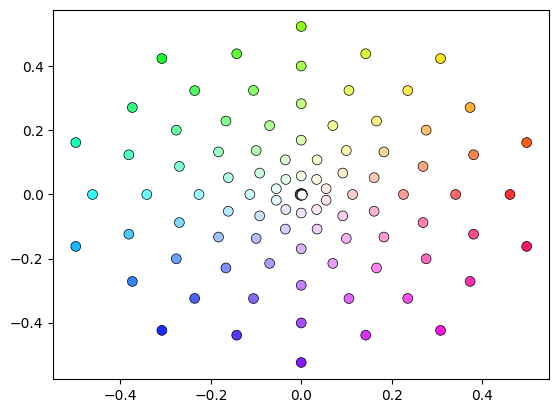

In [ ]:
def get_gaussian_lattice(device='cpu', n_rings=10, n_points=10):
    """
    Generates a fixed 101-point lattice for 2D flow visualization.
    
    Structure:
    - 1 Center point (0,0)
    - n Rings of k points each
    - Radii based on Gaussian probability intervals
    - Alternating phase shift (0, 2pi/k) between rings
    
    Returns:
        z (Tensor): [1+n*k, 2] inputs for the flow inverse.
        colors (Array): [1+n*k, 3] RGB values for plotting the output.
    """

    import torch
    import matplotlib.colors as mcolors

    points = []
    colors_hsv = []

    # --- 1. The Center (Point 0) ---
    points.append([0.0, 0.0])
    # Color: White (Saturation=0, Value=1)
    colors_hsv.append([0.0, 0.0, 1.0]) 

    # --- 2. The 10 Rings ---
    phase_shift = np.pi / n_points  # Alternating shift
    
    # Calculate radii corresponding to equidistant Gaussian probabilities
    # We slice probability space from 51% to 95%
    # This ensures we cover the 'meat' of the distribution and the tails
    probs = torch.linspace(0.501, 0.7, n_rings)
    dist = torch.distributions.Normal(0, 1)
    radii = dist.icdf(probs) # Transform prob -> gaussian radius (sigma)
    max_r = radii[-1].item()

    for i, r in enumerate(radii):
        r = r.item()
        
        # Alternating phase: Even rings start at 0, Odd rings start at pi/20
        # (i starts at 0, so ring 1 is index 0)
        current_phase = phase_shift if (i % 2 != 0) else 0.0
        
        # Generate 10 angles for this ring
        angles = torch.linspace(0, 2*np.pi, n_points + 1)[:-1] + current_phase
        
        # Polar -> Cartesian
        x = r * torch.cos(angles)
        y = r * torch.sin(angles)
        
        # Append points
        ring_points = torch.stack([x, y], dim=1)
        points.append(ring_points)
        
        # --- Color Logic (Polar -> HSV) ---
        # Hue = Angle (normalized 0-1)
        # Saturation = Radius (normalized 0-1)
        # Value = 1.0 (Max brightness)
        
        # Normalize angles to [0, 1] for Hue
        # We use modulo to strictly keep it in range
        hues = (angles % (2*np.pi)) / (2*np.pi)
        
        # Saturation increases with radius (White center -> Vivid edge)
        saturation = r / (max_r * 1.1) # Divide by slightly more than max to avoid clipping
        saturations = torch.full_like(hues, saturation)
        
        values = torch.ones_like(hues) # Full brightness
        
        # Stack HSV for this ring
        ring_hsv = torch.stack([hues, saturations, values], dim=1)
        colors_hsv.append(ring_hsv)

    # --- 3. Assemble Final Tensors ---
    # Concatenate all lists into single tensors
    z_tensor = torch.cat([torch.tensor(points[:1]), torch.cat(points[1:])], dim=0)
    c_tensor_hsv = torch.cat([torch.tensor(colors_hsv[:1]), torch.cat(colors_hsv[1:])], dim=0)
    
    # SAFETY: Clamp HSV values to [0, 1] to prevent matplotlib errors
    c_tensor_hsv = torch.clamp(c_tensor_hsv, 0, 1)
    colors_rgb = mcolors.hsv_to_rgb(c_tensor_hsv.cpu().numpy())
    
    return z_tensor.float().to(device), colors_rgb
# 1. Get the lattice
z_fixed, point_colors = get_gaussian_lattice(device='cpu', n_rings=10, n_points=10)

# 3. Visualize
plt.scatter(z_fixed[:, 0], z_fixed[:, 1], c=point_colors, s=50, edgecolors='k', linewidth=0.5)
plt.show()

In [ ]:
def run_inference_sample(flow, test_loader, y_scaler, target_cols):
    """Run inference using a fixed Gaussian lattice in latent space.

    For each (x, y) in the test set, we:
    - Map all lattice points `z_fixed` through the inverse flow conditioned on x
    - Obtain many samples in y-space, then compute their mean and std per target
    - Collect these means as predictions and compare to true y, like in `run_inference_and_plot`.
    """
    flow.eval()

    y_true_all = []   # inverse-scaled ground truth
    y_mean_all = []   # inverse-scaled lattice means
    y_std_all = []    # inverse-scaled lattice stds

    # Move lattice to device once
    z = z_fixed.to(device)  # shape: [N, 2]
    N = z.shape[0]

    with torch.no_grad():
        for x_batch, y_batch in test_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
            B = x_batch.shape[0]

            # We need to create B copies of the lattice and B copies of x
            # Then flatten to pass through the inverse transform
            
            # Expand x to match each lattice point: [B, N, x_dim] -> [B*N, x_dim]
            x_expanded = x_batch.unsqueeze(1).expand(-1, N, -1).reshape(B * N, -1)
            
            # Expand z to match each batch element: [N, 2] -> [B, N, 2] -> [B*N, 2]
            z_expanded = z.unsqueeze(0).expand(B, -1, -1).reshape(B * N, -1)
            
            # Get conditional distribution for expanded x
            dist = flow(x_expanded)  # conditional distribution p(y|x) for all B*N pairs
            
            # Invert the flow from lattice points in latent space to y-space
            y_samples = dist.transform.inv(z_expanded)  # [B*N, 2]
            
            # Reshape back to [B, N, 2]
            y_samples = y_samples.reshape(B, N, -1)

            # Inverse-scale all samples to original target space
            B, N, D = y_samples.shape
            y_samples_np = y_samples.reshape(B * N, D).cpu().numpy()
            y_samples_unscaled = y_scaler.inverse_transform(y_samples_np).reshape(B, N, D)

            # Mean and std over lattice dimension N for each sample in batch
            means = y_samples_unscaled.mean(axis=1)  # [B, 2]
            stds = y_samples_unscaled.std(axis=1)    # [B, 2]

            y_true_unscaled = y_scaler.inverse_transform(y_batch.cpu().numpy())

            y_true_all.append(y_true_unscaled)
            y_mean_all.append(means)
            y_std_all.append(stds)

    y_true_all = np.concatenate(y_true_all, axis=0)
    y_mean_all = np.concatenate(y_mean_all, axis=0)
    y_std_all = np.concatenate(y_std_all, axis=0)

    # Report overall average std per target
    avg_std = y_std_all.mean(axis=0)
    print(f"Average predicted std for {target_cols[0]} and {target_cols[1]}:", avg_std)

    # Scatter true vs lattice-mean predictions (like original function)
    plt.figure(figsize=(10, 4))

    # Target 0
    plt.subplot(1, 2, 1)
    plt.scatter(y_true_all[:, 0], y_mean_all[:, 0], alpha=0.5)
    plt.xlabel(f"True {target_cols[0]}")
    plt.ylabel(f"Lattice mean {target_cols[0]}")
    plt.title(f"True vs Lattice Mean: {target_cols[0]}")
    plt.plot(
        [y_true_all[:, 0].min(), y_true_all[:, 0].max()],
        [y_true_all[:, 0].min(), y_true_all[:, 0].max()],
        'r--'
    )
    plt.grid()

    # Target 1
    plt.subplot(1, 2, 2)
    plt.scatter(y_true_all[:, 1], y_mean_all[:, 1], alpha=0.5)
    plt.xlabel(f"True {target_cols[1]}")
    plt.ylabel(f"Lattice mean {target_cols[1]}")
    plt.title(f"True vs Lattice Mean: {target_cols[1]}")
    plt.plot(
        [y_true_all[:, 1].min(), y_true_all[:, 1].max()],
        [y_true_all[:, 1].min(), y_true_all[:, 1].max()],
        'r--'
    )
    plt.grid()

    plt.tight_layout()
    plt.show()

In [ ]:
def get_gaussian_lattice(device='cpu', n_rings=10, n_points=10):
    """
    Generates a fixed 101-point lattice for 2D flow visualization.
    
    Structure:
    - 1 Center point (0,0)
    - n Rings of k points each
    - Radii based on Gaussian probability intervals
    - Alternating phase shift (0, 2pi/k) between rings
    
    Returns:
        z (Tensor): [1+n*k, 2] inputs for the flow inverse.
        colors (Array): [1+n*k, 3] RGB values for plotting the output.
    """

    import torch
    import matplotlib.colors as mcolors

    points = []
    colors_hsv = []

    # --- 1. The Center (Point 0) ---
    points.append([0.0, 0.0])
    # Color: White (Saturation=0, Value=1)
    colors_hsv.append([0.0, 0.0, 1.0]) 

    # --- 2. The 10 Rings ---
    phase_shift = np.pi / n_points  # Alternating shift
    
    # Calculate radii corresponding to equidistant Gaussian probabilities
    # We slice probability space from 51% to 95%
    # This ensures we cover the 'meat' of the distribution and the tails
    probs = torch.linspace(0.50, 0.95, n_rings)
    dist = torch.distributions.Normal(0, 1)
    radii = dist.icdf(probs) # Transform prob -> gaussian radius (sigma)
    max_r = radii[-1].item()

    for i, r in enumerate(radii):
        r = r.item()
        
        # Alternating phase: Even rings start at 0, Odd rings start at pi/20
        # (i starts at 0, so ring 1 is index 0)
        current_phase = phase_shift if (i % 2 != 0) else 0.0
        
        # Generate 10 angles for this ring
        angles = torch.linspace(0, 2*np.pi, n_points + 1)[:-1] + current_phase
        
        # Polar -> Cartesian
        x = r * torch.cos(angles)
        y = r * torch.sin(angles)
        
        # Append points
        ring_points = torch.stack([x, y], dim=1)
        points.append(ring_points)
        
        # --- Color Logic (Polar -> HSV) ---
        # Hue = Angle (normalized 0-1)
        # Saturation = Radius (normalized 0-1)
        # Value = 1.0 (Max brightness)
        
        # Normalize angles to [0, 1] for Hue
        # We use modulo to strictly keep it in range
        hues = (angles % (2*np.pi)) / (2*np.pi)
        
        # Saturation increases with radius (White center -> Vivid edge)
        saturation = r / (max_r * 1.1) # Divide by slightly more than max to avoid clipping
        saturations = torch.full_like(hues, saturation)
        
        values = torch.ones_like(hues) # Full brightness
        
        # Stack HSV for this ring
        ring_hsv = torch.stack([hues, saturations, values], dim=1)
        colors_hsv.append(ring_hsv)

    # --- 3. Assemble Final Tensors ---
    # Concatenate all lists into single tensors
    z_tensor = torch.cat([torch.tensor(points[:1]), torch.cat(points[1:])], dim=0)
    c_tensor_hsv = torch.cat([torch.tensor(colors_hsv[:1]), torch.cat(colors_hsv[1:])], dim=0)
    
    # SAFETY: Clamp HSV values to [0, 1] to prevent matplotlib errors
    c_tensor_hsv = torch.clamp(c_tensor_hsv, 0, 1)
    colors_rgb = mcolors.hsv_to_rgb(c_tensor_hsv.cpu().numpy())
    
    return z_tensor.float().to(device), colors_rgb

Average predicted std for DAMAGES and CASUALTIES: [2.3542866e-01 1.1089310e-06]


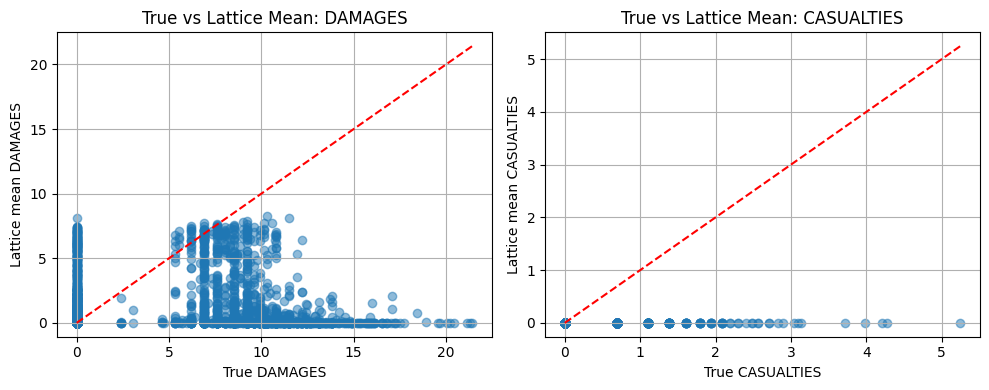

In [ ]:
run_inference_sample(flow, test_loader, y_scaler, TARGET_COLS)


In [ ]:
def run_inference_map(flow, test_loader, y_scaler, target_cols, 
                      n_iterations=100, lr=0.01, n_init_points=10):
    """Run inference by finding MAP (maximum a posteriori) estimates in latent space.

    For each (x, y) in the test set, we:
    - Initialize multiple points in latent space
    - Use gradient ascent to maximize log p(z|x) for each initialization
    - Take the best (highest probability) point from all initializations
    - Invert through the flow once to get the MAP estimate in y-space
    - Compare to true y
    """
    flow.eval()

    y_true_all = []   # inverse-scaled ground truth
    y_map_all = []    # inverse-scaled MAP estimates
    log_probs_all = []  # log probabilities at MAP

    for x_batch, y_batch in test_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)
        B = x_batch.shape[0]

        # Store best z and log_prob for each sample in batch
        best_z = torch.zeros(B, 2, device=device)
        best_log_prob = torch.full((B,), float('-inf'), device=device)

        # Try multiple random initializations
        for init_idx in range(n_init_points):
            # Initialize z from standard normal (requires_grad=True for optimization)
            z = torch.randn(B, 2, device=device, requires_grad=True)
            
            # Optimizer for this initialization
            optimizer = torch.optim.Adam([z], lr=lr)
            
            # Gradient ascent loop
            for iter_idx in range(n_iterations):
                optimizer.zero_grad()
                
                # Compute log probability of z under the base distribution
                # p(z) = N(0, I), so log p(z) = -0.5 * (z^2).sum(dim=-1) - const
                log_prob_z = -0.5 * (z ** 2).sum(dim=-1)
                
                # We want to maximize log p(z), so minimize negative log p(z)
                loss = -log_prob_z.mean()
                
                loss.backward()
                optimizer.step()
            
            # After optimization, check if this initialization is better
            with torch.no_grad():
                final_log_prob = -0.5 * (z ** 2).sum(dim=-1)
                
                # Update best_z for samples where this init is better
                mask = final_log_prob > best_log_prob
                best_z[mask] = z[mask].detach()
                best_log_prob[mask] = final_log_prob[mask]

        # Now invert the best z values through the flow (only once!)
        with torch.no_grad():
            dist = flow(x_batch)
            y_map = dist.transform.inv(best_z)  # [B, 2]
            
            # Inverse-scale to original target space
            y_map_np = y_map.cpu().numpy()
            y_map_unscaled = y_scaler.inverse_transform(y_map_np)
            
            y_true_unscaled = y_scaler.inverse_transform(y_batch.cpu().numpy())
            
            y_true_all.append(y_true_unscaled)
            y_map_all.append(y_map_unscaled)
            log_probs_all.append(best_log_prob.cpu().numpy())

    y_true_all = np.concatenate(y_true_all, axis=0)
    y_map_all = np.concatenate(y_map_all, axis=0)
    log_probs_all = np.concatenate(log_probs_all, axis=0)

    # Report statistics
    print(f"Average MAP log probability: {log_probs_all.mean():.4f}")
    print(f"Std of MAP log probability: {log_probs_all.std():.4f}")

    # Compute errors
    mse_0 = np.mean((y_true_all[:, 0] - y_map_all[:, 0]) ** 2)
    mse_1 = np.mean((y_true_all[:, 1] - y_map_all[:, 1]) ** 2)
    print(f"MSE for {target_cols[0]}: {mse_0:.4f}")
    print(f"MSE for {target_cols[1]}: {mse_1:.4f}")

    # Scatter true vs MAP predictions
    plt.figure(figsize=(10, 4))

    # Target 0
    plt.subplot(1, 2, 1)
    plt.scatter(y_true_all[:, 0], y_map_all[:, 0], alpha=0.5, 
                c=log_probs_all, cmap='viridis')
    plt.colorbar(label='Log Probability')
    plt.xlabel(f"True {target_cols[0]}")
    plt.ylabel(f"MAP {target_cols[0]}")
    plt.title(f"True vs MAP: {target_cols[0]}")
    plt.plot(
        [y_true_all[:, 0].min(), y_true_all[:, 0].max()],
        [y_true_all[:, 0].min(), y_true_all[:, 0].max()],
        'r--'
    )
    plt.grid()

    # Target 1
    plt.subplot(1, 2, 2)
    plt.scatter(y_true_all[:, 1], y_map_all[:, 1], alpha=0.5,
                c=log_probs_all, cmap='viridis')
    plt.colorbar(label='Log Probability')
    plt.xlabel(f"True {target_cols[1]}")
    plt.ylabel(f"MAP {target_cols[1]}")
    plt.title(f"True vs MAP: {target_cols[1]}")
    plt.plot(
        [y_true_all[:, 1].min(), y_true_all[:, 1].max()],
        [y_true_all[:, 1].min(), y_true_all[:, 1].max()],
        'r--'
    )
    plt.grid()

    plt.tight_layout()
    plt.show()
    
    return y_true_all, y_map_all, log_probs_all

Average MAP log probability: -0.0004
Std of MAP log probability: 0.0027
MSE for DAMAGES: 11.6810
MSE for CASUALTIES: 0.0427


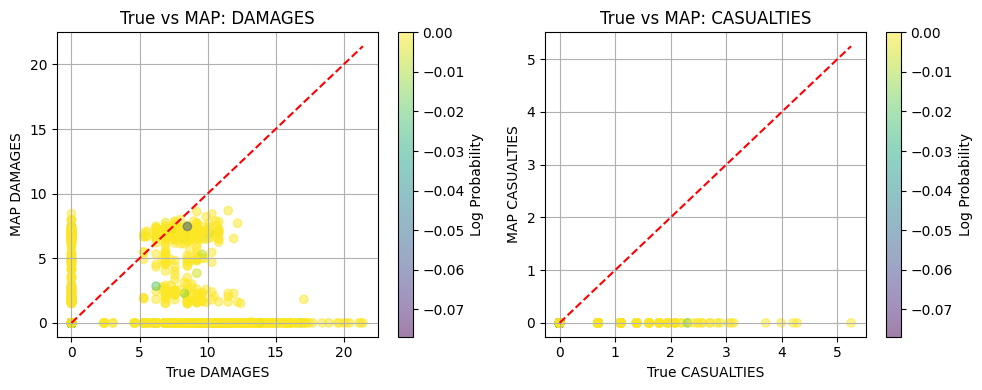

In [ ]:
y_true, y_map, log_probs = run_inference_map(
    flow, test_loader, y_scaler, TARGET_COLS,
    n_iterations=100,  # gradient ascent steps per initialization
    lr=0.01,           # learning rate
    n_init_points=10   # number of random initializations
)

In [ ]:
def visualize_single_training_example(flow, X_train, Y_train, idx, z_fixed, y_scaler, target_cols):
    """
    For one training example:
    - show its location in original 2D (damages, casualties)
    - show its latent z
    - show lattice in z and where that lattice maps in y (original space),
      all conditioned on the same context x[idx].
    """
    device = next(flow.parameters()).device

    # 1. Pick one training example (context + target) in standardized/log space
    x0 = X_train[idx:idx+1].to(device)   # [1, X_DIM]
    y0 = Y_train[idx:idx+1].to(device)   # [1, 2]

    with torch.no_grad():
        dist0 = flow(x0)                 # conditional p(y|x0)

        # 2. Map this y0 to latent space z0: y -> z
        z0 = dist0.transform.inv(y0)     # [1, 2]

        # 3. Map the lattice from latent space to y-space: z_lattice -> y_lattice
        z_latent = z_fixed.to(device)    # [N, 2]
        y_lattice = dist0.transform(z_latent)  # [N, 2]

    # 4. Undo scaling/log to get back to original damages/casualties
    y0_np = y0.cpu().numpy()
    y0_unscaled = np.expm1(y_scaler.inverse_transform(y0_np))[0]      # (2,)

    y_lattice_np = y_lattice.cpu().numpy()
    y_lattice_unscaled = np.expm1(y_scaler.inverse_transform(y_lattice_np))  # (N, 2)

    # 5. Prepare latent arrays for plotting
    z0_np = z0.cpu().numpy()[0]          # (2,)
    z_latent_np = z_latent.cpu().numpy() # (N, 2)

    # 6. Plots
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    # Left: original 2D target space (DAMAGES, CASUALTIES)
    ax = axes[0]
    ax.scatter(
        y_lattice_unscaled[:, 0], y_lattice_unscaled[:, 1],
        c=point_colors, s=40, alpha=0.7, edgecolors="k", linewidth=0.3,
        label="Lattice mapped to y"
    )
    ax.scatter(
        y0_unscaled[0], y0_unscaled[1],
        color="red", s=80, marker="x", label="Training example"
    )

    # Set limits to include both lattice and point, with a small margin
    xs = np.concatenate([y_lattice_unscaled[:,0], [y0_unscaled[0]]])
    ys = np.concatenate([y_lattice_unscaled[:,1], [y0_unscaled[1]]])
    x_min, x_max = xs.min(), xs.max()
    y_min, y_max = ys.min(), ys.max()
    margin_x = 0.05 * (x_max - x_min + 1e-6)
    margin_y = 0.05 * (y_max - y_min + 1e-6)
    ax.set_xlim(x_min - margin_x, x_max + margin_x)
    ax.set_ylim(y_min - margin_y, y_max + margin_y)

    ax.set_xlabel(target_cols[0])
    ax.set_ylabel(target_cols[1])
    ax.set_title("Original space (y) conditioned on x[idx]")
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Right: latent space z
    ax = axes[1]
    ax.scatter(
        z_latent_np[:, 0], z_latent_np[:, 1],
        c=point_colors, s=40, alpha=0.7, edgecolors="k", linewidth=0.3,
        label="Lattice in z"
    )
    ax.scatter(
        z0_np[0], z0_np[1],
        color="red", s=60, marker="x", label="z of training y"
    )
    ax.set_xlabel("z1")
    ax.set_ylabel("z2")
    ax.set_title("Latent space (z) conditioned on x[idx]")
    ax.axhline(0, color="k", linestyle="--", alpha=0.3)
    ax.axvline(0, color="k", linestyle="--", alpha=0.3)
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

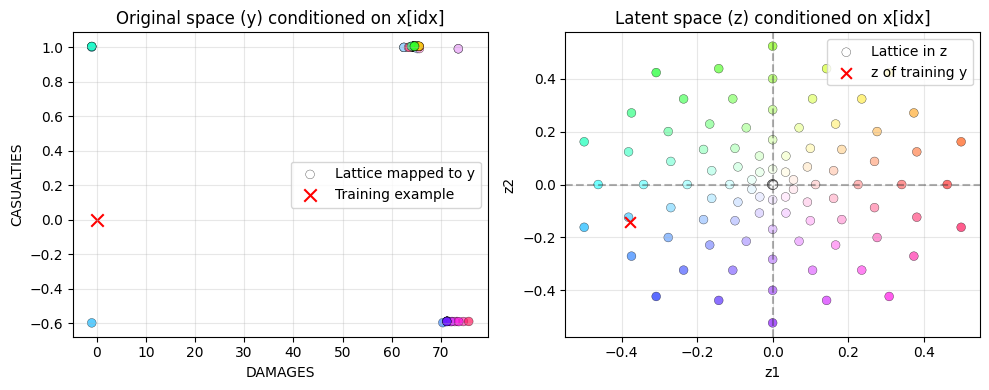

In [ ]:
idx = 1  # or any training index
visualize_single_training_example(flow, X_train, Y_train, idx, z_fixed, y_scaler, TARGET_COLS)

## Result Analysis — Monte Carlo CI and Calibration

Using the NSF's distributional output: Monte Carlo sampling for confidence intervals, coverage analysis, and uncertainty–feature correlation.

In [ ]:
def batch_mc_samples(flow, X_test, Y_test, y_scaler, n_samples=2000, device='cpu'):
    """
    Draw Monte Carlo samples from the NSF for each test point.
    Returns samples and true values in original scale (after expm1).
    """
    flow.eval()
    X_test = X_test.to(device)
    n_test = X_test.shape[0]
    all_samples = np.zeros((n_test, n_samples, 2), dtype=np.float32)

    with torch.no_grad():
        for i in range(n_test):
            x = X_test[i:i+1]  # (1, X_DIM)
            dist = flow(x)
            samples = dist.sample((n_samples,)).squeeze(1).cpu().numpy()  # (n_samples, 2)
            samples = y_scaler.inverse_transform(samples)
            samples = np.expm1(np.clip(samples, -20, None))
            samples[:, 1] = np.floor(samples[:, 1]).clip(0)  # CASUALTIES non-negative
            all_samples[i] = samples

    y_true_scaled = Y_test.cpu().numpy()
    y_true_orig = y_scaler.inverse_transform(y_true_scaled)
    y_true_orig = np.expm1(np.clip(y_true_orig, -20, None))
    y_true_orig[:, 1] = np.floor(y_true_orig[:, 1]).clip(0)

    return all_samples, y_true_orig

In [ ]:
N_MC_SAMPLES = 2000
all_samples, y_true_orig = batch_mc_samples(flow, X_test, Y_test, y_scaler, n_samples=N_MC_SAMPLES, device=device)
print(f"all_samples shape: {all_samples.shape}, y_true_orig shape: {y_true_orig.shape}")

all_samples shape: (7454, 2000, 2), y_true_orig shape: (7454, 2)


### Calibration: Empirical CI Coverage

Does the model produce well-calibrated intervals? For 50%, 80%, and 95% CIs, we check whether the true value falls inside.

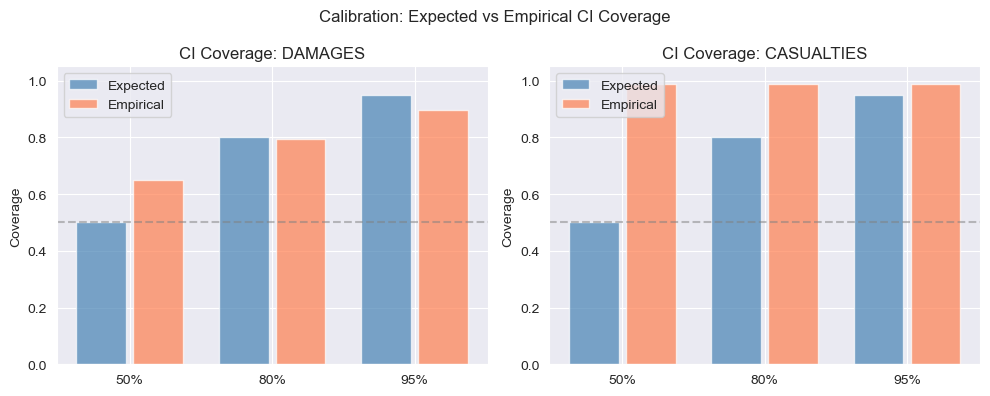

In [ ]:
ci_levels = [0.50, 0.80, 0.95]
coverage = {col: [] for col in TARGET_COLS}

for level in ci_levels:
    lo = (1 - level) / 2
    hi = 1 - lo
    for j, col in enumerate(TARGET_COLS):
        q_lo = np.percentile(all_samples[:, :, j], lo * 100, axis=1)
        q_hi = np.percentile(all_samples[:, :, j], hi * 100, axis=1)
        inside = (y_true_orig[:, j] >= q_lo) & (y_true_orig[:, j] <= q_hi)
        coverage[col].append(inside.mean())

sns.set_style("darkgrid")
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (col, cov) in zip(axes, coverage.items()):
    x = np.arange(len(ci_levels))
    bars = ax.bar(x - 0.2, ci_levels, 0.35, label='Expected', alpha=0.7, color='steelblue')
    bars2 = ax.bar(x + 0.2, cov, 0.35, label='Empirical', alpha=0.7, color='coral')
    ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels([f'{int(l*100)}%' for l in ci_levels])
    ax.set_ylabel('Coverage')
    ax.set_title(f'CI Coverage: {col}')
    ax.legend()
    ax.set_ylim(0, 1.05)
plt.suptitle('Calibration: Expected vs Empirical CI Coverage')
plt.tight_layout()
plt.show()

### PIT Histogram (Probability Integral Transform)

For each test point, we compute the percentile rank of the true value within the sampled distribution. A well-calibrated model yields a uniform histogram.

**If the PIT looks Gaussian (central bulge) instead of uniform, possible causes:**
- **Underconfidence**: Predicted distributions are too wide; true values often fall near the median, clustering PIT around 0.5.
- **Regression to the mean**: In heavy-tailed data, extreme true values may be underpredicted; moderate values overpredicted.
- **Model misfit**: The flow may not fully capture the conditional variance structure.

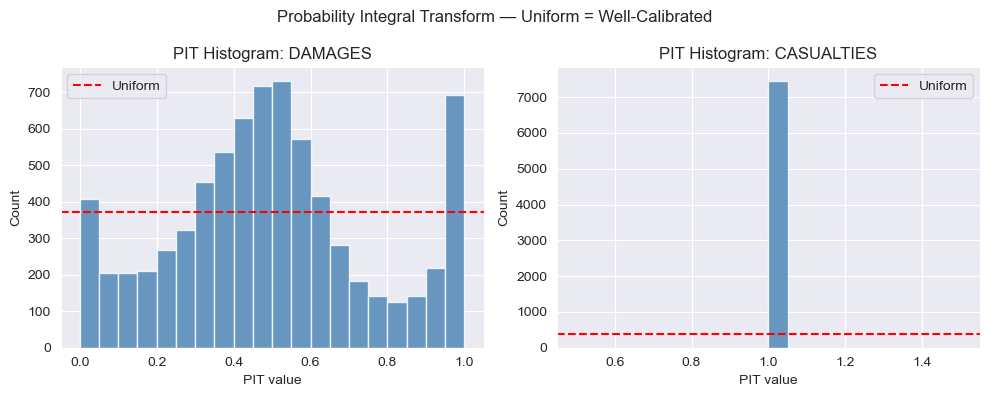

In [ ]:
pit_values = np.zeros_like(y_true_orig)
for i in range(len(y_true_orig)):
    for j in range(2):
        pit_values[i, j] = np.mean(all_samples[i, :, j] <= y_true_orig[i, j])

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (col, j) in zip(axes, [(TARGET_COLS[0], 0), (TARGET_COLS[1], 1)]):
    ax.hist(pit_values[:, j], bins=20, edgecolor='white', alpha=0.8, color='steelblue')
    ax.axhline(len(pit_values) / 20, color='red', linestyle='--', label='Uniform')
    ax.set_xlabel('PIT value')
    ax.set_ylabel('Count')
    ax.set_title(f'PIT Histogram: {col}')
    ax.legend()
plt.suptitle('Probability Integral Transform — Uniform = Well-Calibrated')
plt.tight_layout()
plt.show()

### Individual Conditional Distributions

Three representative events: low, medium, and high damage. MC samples with KDE density coloring; true value marked in red.

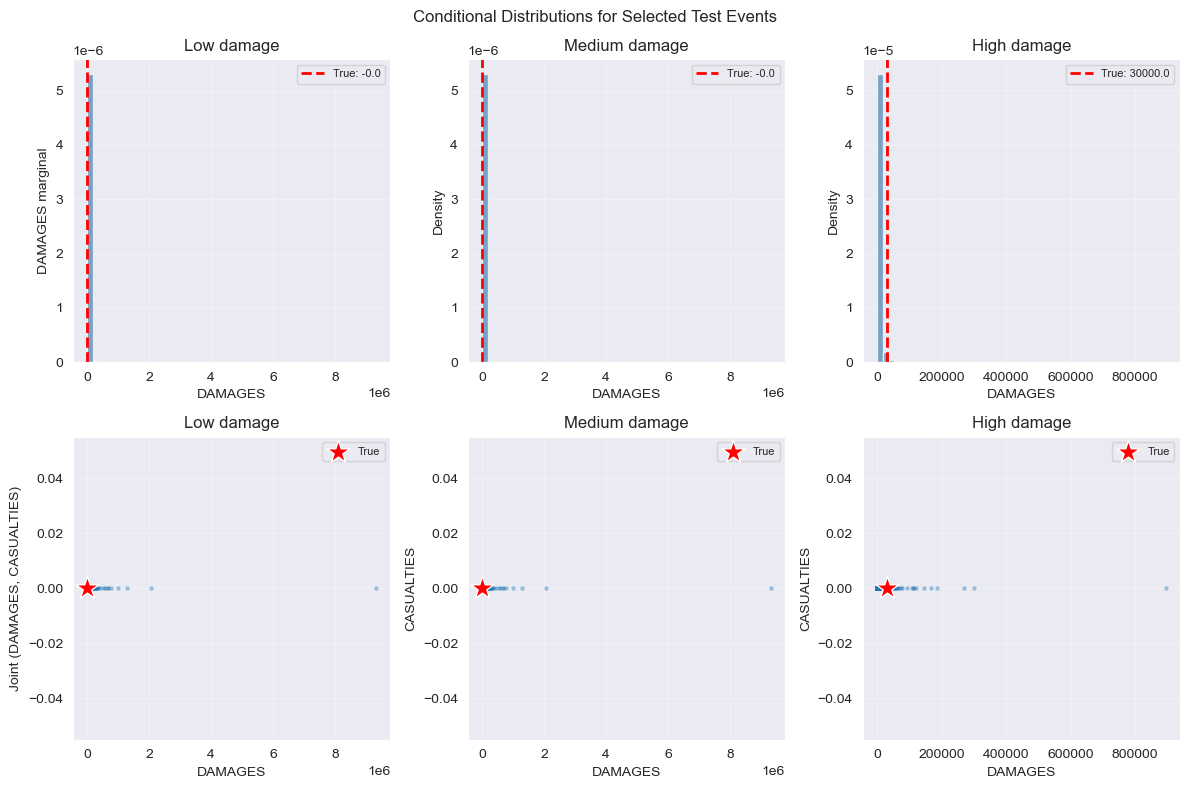

In [ ]:
# Select low, medium, high damage indices by DAMAGES
damages = y_true_orig[:, 0]
q_low = np.percentile(damages, 10)
q_mid = np.percentile(damages, 50)
q_hi = np.percentile(damages, 90)
idx_low = np.argmin(np.abs(damages - q_low))
idx_mid = np.argmin(np.abs(damages - q_mid))
idx_hi = np.argmin(np.abs(damages - q_hi))
indices = [idx_low, idx_mid, idx_hi]
labels = ['Low damage', 'Medium damage', 'High damage']

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for col, (ax_row, j) in enumerate(zip(axes, [0, 1])):
    for ax, (idx, lbl) in zip(ax_row, zip(indices, labels)):
        samples_j = all_samples[idx, :, j]
        true_val = y_true_orig[idx, j]
        if col == 0:
            ax.hist(samples_j, bins=50, density=True, alpha=0.7, color='steelblue', edgecolor='white')
            ax.axvline(true_val, color='red', linewidth=2, linestyle='--', label=f'True: {true_val:.1f}')
        else:
            # 2D: DAMAGES vs CASUALTIES for this sample
            s0, s1 = all_samples[idx, :, 0], all_samples[idx, :, 1]
            try:
                xy = np.vstack([s0, s1])
                z = gaussian_kde(xy)(xy)
                ax.scatter(s0, s1, c=z, s=5, cmap='viridis', alpha=0.6)
            except np.linalg.LinAlgError:
                ax.scatter(s0, s1, alpha=0.3, s=5)
            ax.scatter(y_true_orig[idx, 0], y_true_orig[idx, 1], marker='*', s=300, c='red', edgecolor='white', zorder=5, label='True')
        ax.set_title(f'{lbl}')
        if col == 0:
            ax.set_xlabel(TARGET_COLS[j])
            ax.set_ylabel('Density')
        else:
            ax.set_xlabel(TARGET_COLS[0])
            ax.set_ylabel(TARGET_COLS[1])
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
axes[0, 0].set_ylabel('DAMAGES marginal')
axes[1, 0].set_ylabel('Joint (DAMAGES, CASUALTIES)')
plt.suptitle('Conditional Distributions for Selected Test Events')
plt.tight_layout()
plt.show()

### Uncertainty vs Input Features

Which input conditions correlate with wider (higher uncertainty) or narrower (higher confidence) 95% CIs?

C:\Users\xPica\AppData\Local\Temp\ipykernel_21940\2612865304.py:11: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r_c, _ = stats.spearmanr(X_test_orig[:, k], ci_width_casualties)
C:\Users\xPica\AppData\Local\Temp\ipykernel_21940\2612865304.py:10: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r_d, _ = stats.spearmanr(X_test_orig[:, k], ci_width_damages)


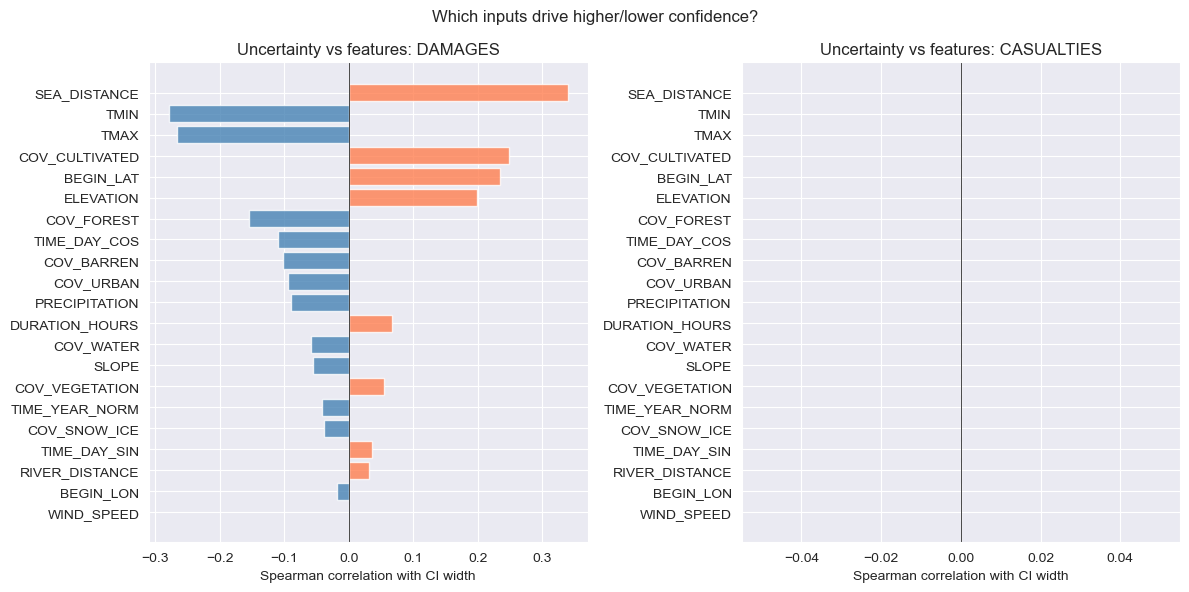

In [ ]:
# 95% CI width for each test point and target
ci_lo, ci_hi = np.percentile(all_samples, [2.5, 97.5], axis=1)
ci_width_damages = np.log1p(ci_hi[:, 0]) - np.log1p(ci_lo[:, 0])  # log-scale width more interpretable
ci_width_casualties = ci_hi[:, 1] - ci_lo[:, 1]

X_test_orig = x_scaler.inverse_transform(X_test.cpu().numpy())
corr_damages = []
corr_casualties = []
for k in range(X_test_orig.shape[1]):
    r_d, _ = stats.spearmanr(X_test_orig[:, k], ci_width_damages)
    r_c, _ = stats.spearmanr(X_test_orig[:, k], ci_width_casualties)
    corr_damages.append(np.nan_to_num(r_d, nan=0.0))
    corr_casualties.append(np.nan_to_num(r_c, nan=0.0))

df_corr = pd.DataFrame({
    'feature': X_COLS,
    'DAMAGES': corr_damages,
    'CASUALTIES': corr_casualties
})
df_corr['abs_D'] = np.abs(df_corr['DAMAGES'])
df_corr = df_corr.sort_values('abs_D', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
colors_d = ['coral' if c > 0 else 'steelblue' for c in df_corr['DAMAGES']]
colors_c = ['coral' if c > 0 else 'steelblue' for c in df_corr['CASUALTIES']]
axes[0].barh(df_corr['feature'], df_corr['DAMAGES'], color=colors_d, alpha=0.8)
axes[0].axvline(0, color='black', linewidth=0.5)
axes[0].set_xlabel('Spearman correlation with CI width')
axes[0].set_title(f'Uncertainty vs features: {TARGET_COLS[0]}')
axes[1].barh(df_corr['feature'], df_corr['CASUALTIES'], color=colors_c, alpha=0.8)
axes[1].axvline(0, color='black', linewidth=0.5)
axes[1].set_xlabel('Spearman correlation with CI width')
axes[1].set_title(f'Uncertainty vs features: {TARGET_COLS[1]}')
plt.suptitle('Which inputs drive higher/lower confidence?')
plt.tight_layout()
plt.show()

### Conditional Sensitivity: How Outputs Change with Key Features

Fix all features at the median; sweep each feature from 5th to 95th percentile. DAMAGES only, 2 plots per row.

In [ ]:
print(X_COLS)

['BEGIN_LAT', 'BEGIN_LON', 'DURATION_HOURS', 'WIND_SPEED', 'TIME_DAY_SIN', 'TIME_DAY_COS', 'TIME_YEAR_NORM', 'PRECIPITATION', 'TMIN', 'TMAX', 'ELEVATION', 'SLOPE', 'COV_BARREN', 'COV_CULTIVATED', 'COV_VEGETATION', 'COV_FOREST', 'COV_WATER', 'COV_SNOW_ICE', 'COV_URBAN', 'RIVER_DISTANCE', 'SEA_DISTANCE']


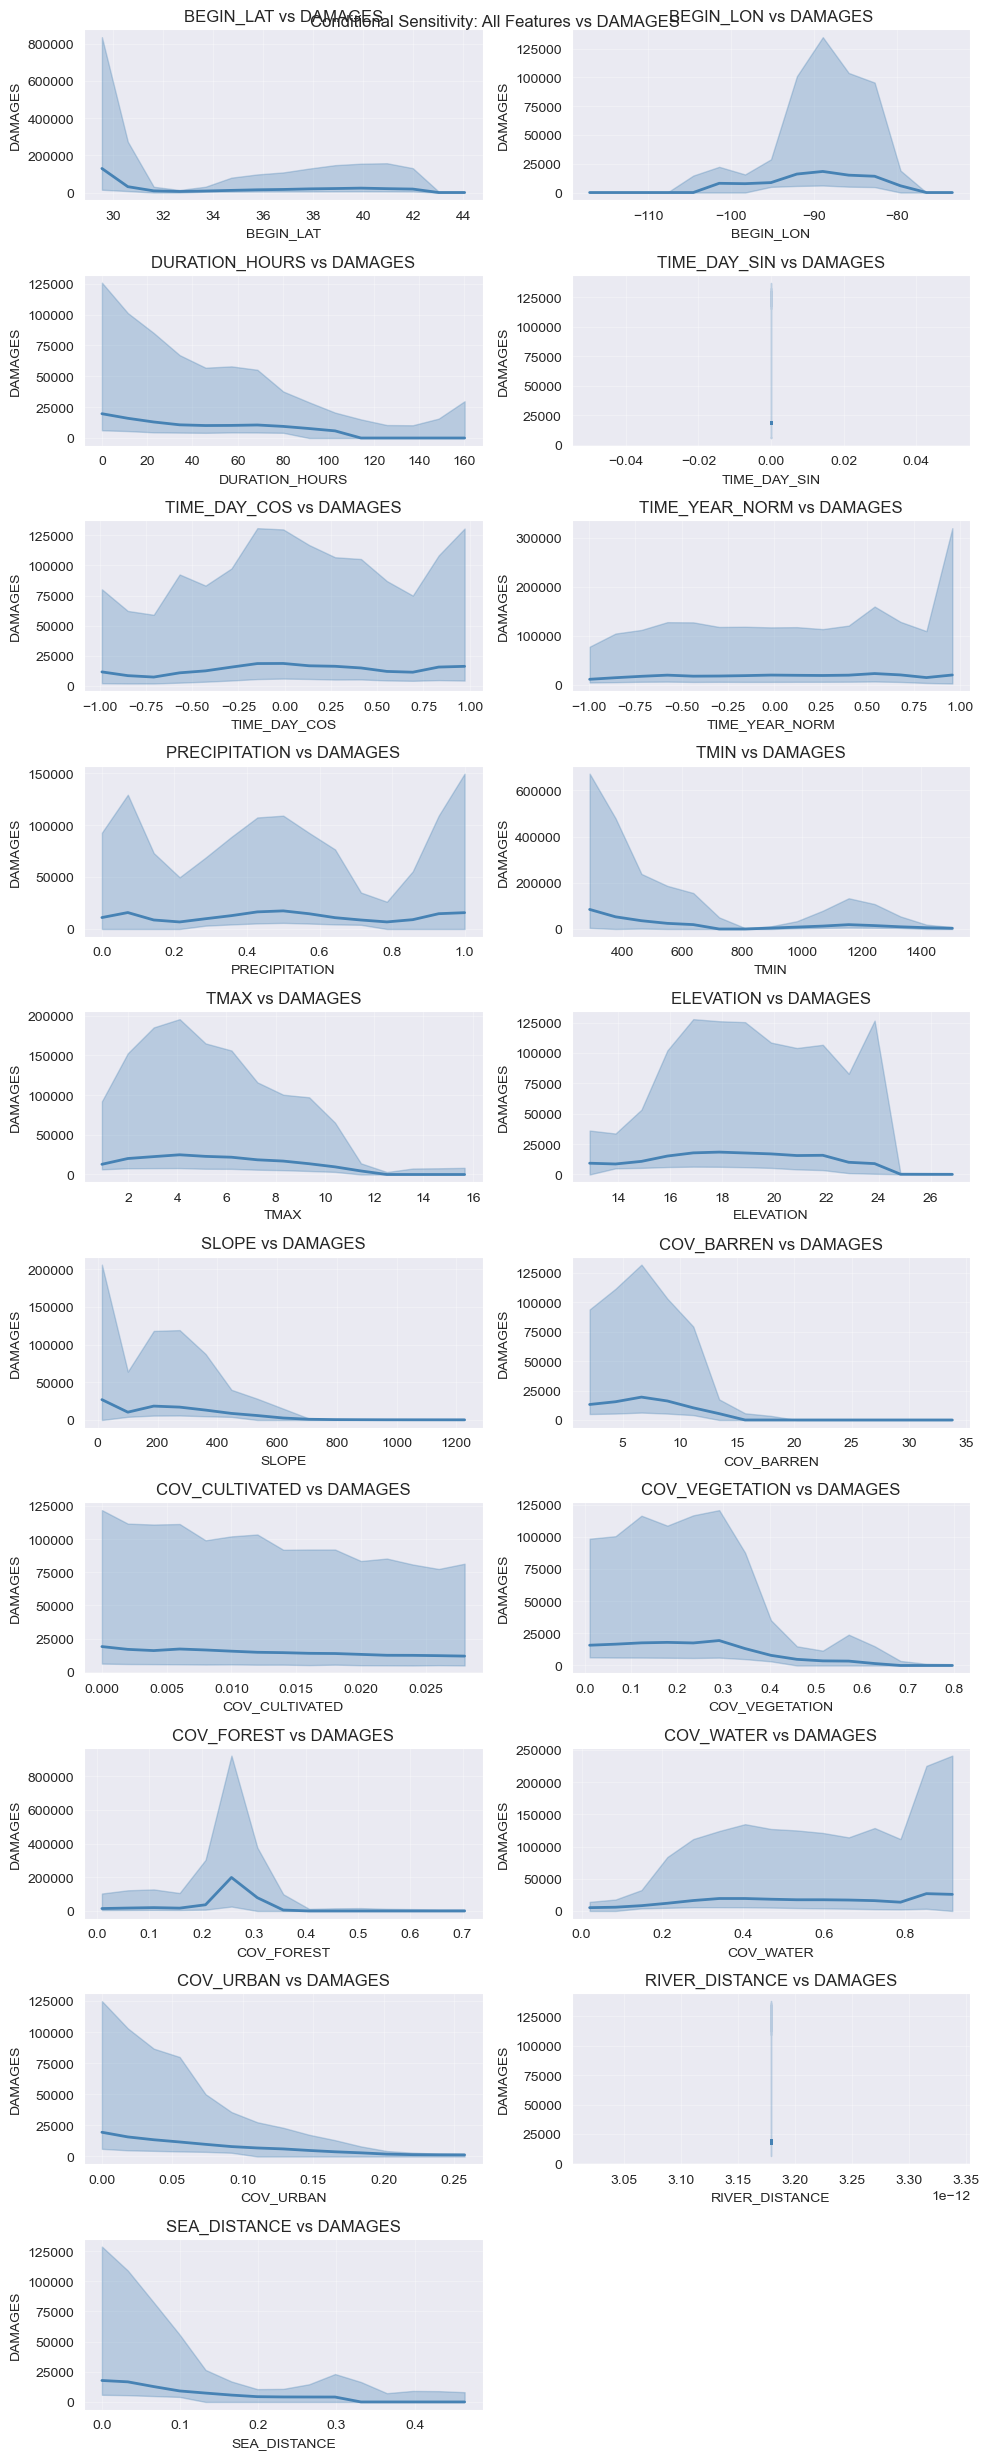

In [ ]:
# Median context (scaled)
x_median = np.median(X_test_orig, axis=0)
n_sweep = 15
n_samples_sweep = 2000
j = 0  # DAMAGES only

used_features =['BEGIN_LAT', 'BEGIN_LON', 'DURATION_HOURS', 'TIME_DAY_SIN', 'TIME_DAY_COS', 'TIME_YEAR_NORM', 'PRECIPITATION', 'TMIN', 'TMAX', 'ELEVATION', 'SLOPE', 'COV_BARREN', 'COV_CULTIVATED', 'COV_VEGETATION', 'COV_FOREST', 'COV_WATER', 'COV_URBAN', 'RIVER_DISTANCE', 'SEA_DISTANCE']

n_features = len(used_features)
n_cols = 2
n_rows = (n_features + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 2.5 * n_rows))
axes = np.atleast_2d(axes)

for idx, (feat_name, feat_idx) in enumerate(zip(used_features, range(n_features))):
    ax = axes.flat[idx]
    vals_orig = np.linspace(np.percentile(X_test_orig[:, feat_idx], 5),
                            np.percentile(X_test_orig[:, feat_idx], 95), n_sweep)
    medians, lo80, hi80 = [], [], []
    for v in vals_orig:
        x_ctx = x_median.copy()
        x_ctx[feat_idx] = v
        x_scaled = torch.tensor(x_scaler.transform(x_ctx.reshape(1, -1)), dtype=torch.float32).to(device)
        with torch.no_grad():
            dist = flow(x_scaled)
            samples = dist.sample((n_samples_sweep,)).squeeze(1).cpu().numpy()
        samples = y_scaler.inverse_transform(samples)
        samples = np.expm1(np.clip(samples, -20, None))
        samples[:, 1] = np.floor(samples[:, 1]).clip(0)
        medians.append(np.median(samples[:, j]))
        lo80.append(np.percentile(samples[:, j], 10))
        hi80.append(np.percentile(samples[:, j], 90))
    medians, lo80, hi80 = np.array(medians), np.array(lo80), np.array(hi80)
    ax.fill_between(vals_orig, lo80, hi80, alpha=0.3, color='steelblue')
    ax.plot(vals_orig, medians, color='steelblue', linewidth=2)
    ax.set_xlabel(feat_name)
    ax.set_ylabel(TARGET_COLS[0])
    ax.set_title(f'{feat_name} vs {TARGET_COLS[0]}')
    ax.grid(True, alpha=0.3)

for idx in range(n_features, n_rows * n_cols):
    axes.flat[idx].set_visible(False)
plt.suptitle('Conditional Sensitivity: All Features vs DAMAGES')
plt.tight_layout()
plt.show()

### Geographic Calibration Map

Events colored by which targets fall inside the CI: both correct (green), damages only (blue), casualties only (orange), both wrong (red). Separate map for each coverage level.

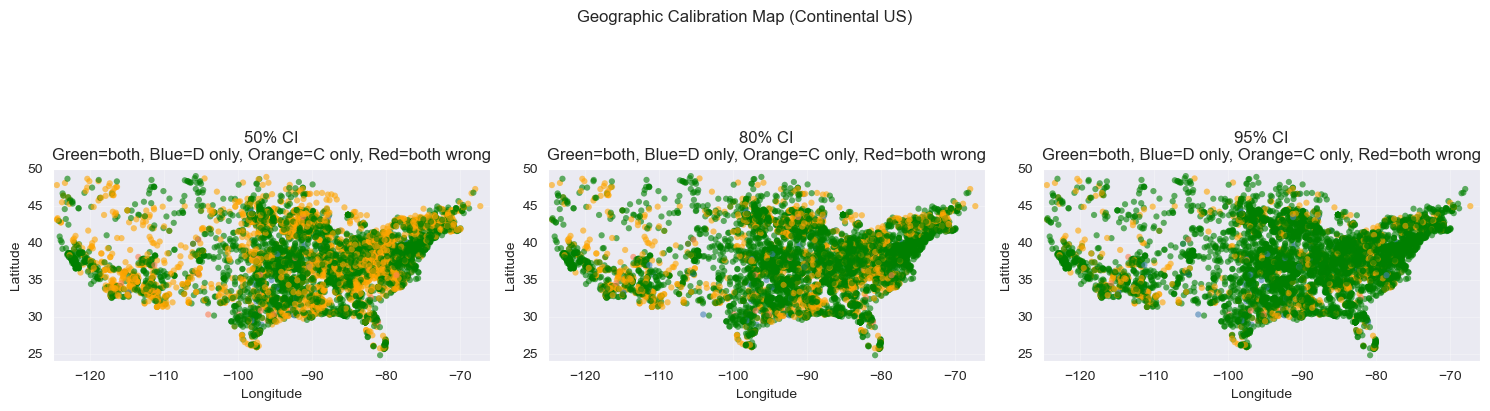

In [ ]:
lat_idx = X_COLS.index('BEGIN_LAT')
lon_idx = X_COLS.index('BEGIN_LON')
lats = X_test_orig[:, lat_idx]
lons = X_test_orig[:, lon_idx]

# Continental US bounds (approx)
LAT_MIN, LAT_MAX = 24, 50
LON_MIN, LON_MAX = -125, -66
mask_us = (lats >= LAT_MIN) & (lats <= LAT_MAX) & (lons >= LON_MIN) & (lons <= LON_MAX)
lats_us, lons_us = lats[mask_us], lons[mask_us]

# Coverage levels: (level_name, lo_pct, hi_pct)
coverage_configs = [(50, 25, 75), (80, 10, 90), (95, 2.5, 97.5)]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (level, lo, hi) in zip(axes, coverage_configs):
    inside_d = (y_true_orig[:, 0] >= np.percentile(all_samples[:, :, 0], lo, axis=1)) & \
               (y_true_orig[:, 0] <= np.percentile(all_samples[:, :, 0], hi, axis=1))
    inside_c = (y_true_orig[:, 1] >= np.percentile(all_samples[:, :, 1], lo, axis=1)) & \
               (y_true_orig[:, 1] <= np.percentile(all_samples[:, :, 1], hi, axis=1))
    inside_d_us = inside_d[mask_us]
    inside_c_us = inside_c[mask_us]

    # 4 categories: both, damages only, casualties only, both wrong
    both_ok = inside_d_us & inside_c_us
    d_only = inside_d_us & ~inside_c_us
    c_only = ~inside_d_us & inside_c_us
    both_wrong = ~inside_d_us & ~inside_c_us

    colors = np.where(both_ok, 'green', np.where(d_only, 'steelblue', np.where(c_only, 'orange', 'coral')))
    ax.scatter(lons_us, lats_us, c=colors, alpha=0.6, s=20, edgecolors='none')
    ax.set_xlim(LON_MIN, LON_MAX)
    ax.set_ylim(LAT_MIN, LAT_MAX)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.set_title(f'{level}% CI\nGreen=both, Blue=D only, Orange=C only, Red=both wrong')
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
plt.suptitle('Geographic Calibration Map (Continental US)')
plt.tight_layout()
plt.show()

### Geographic CI Width Map

Events colored by 95% CI width (gradient): dark = narrow/confident, bright = wide/uncertain.

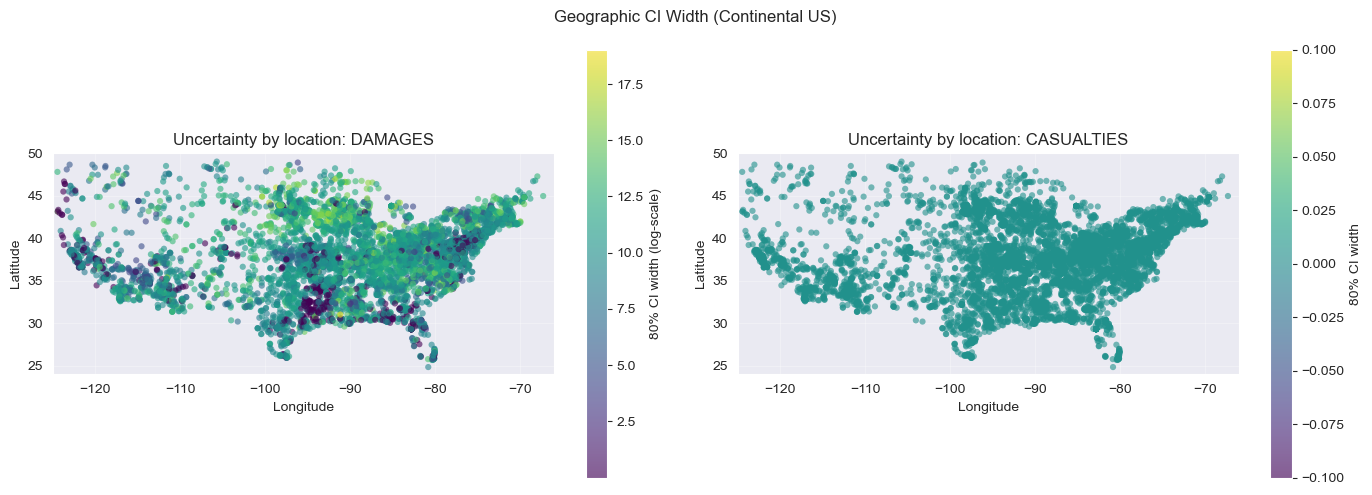

In [ ]:
ci_width_damages_us = ci_width_damages[mask_us]
ci_width_casualties_us = ci_width_casualties[mask_us]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (widths, col, label) in zip(axes, [(ci_width_damages_us, TARGET_COLS[0], '80% CI width (log-scale)'),
                                            (ci_width_casualties_us, TARGET_COLS[1], '80% CI width')]):
    sc = ax.scatter(lons_us, lats_us, c=widths, cmap='viridis', alpha=0.6, s=20, edgecolors='none')
    ax.set_xlim(LON_MIN, LON_MAX)
    ax.set_ylim(LAT_MIN, LAT_MAX)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.set_title(f'Uncertainty by location: {col}')
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    plt.colorbar(sc, ax=ax, label=label)
plt.suptitle('Geographic CI Width (Continental US)')
plt.tight_layout()
plt.show()

### True vs Predicted Colored by CI Width

Scatter of true vs predicted median; color indicates uncertainty (CI width). Reveals whether high-uncertainty predictions correlate with larger errors.

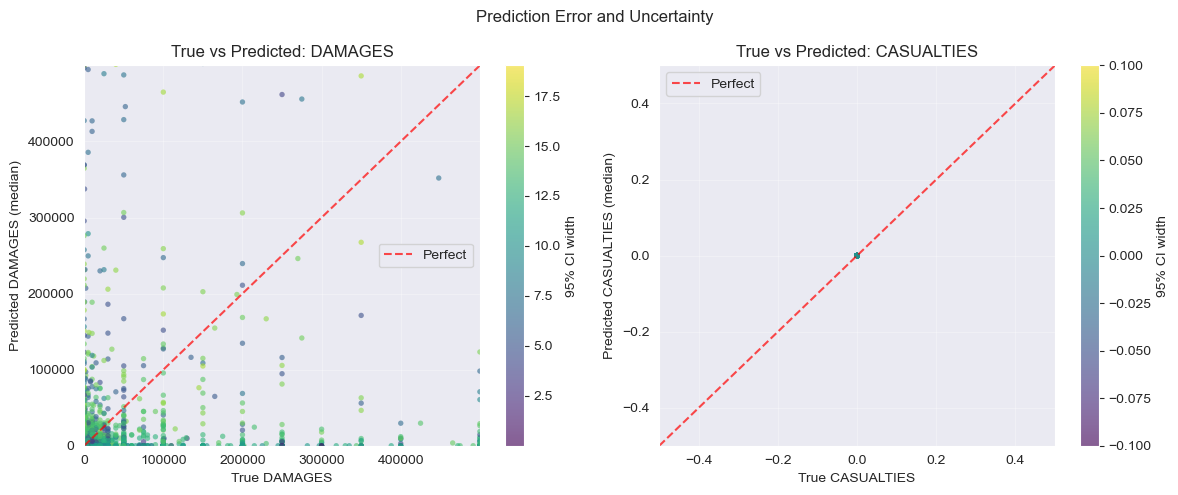

In [ ]:
pred_median = np.median(all_samples, axis=1)  # (n_test, 2)

# Percentile-based limits to avoid outliers zooming out the view (2nd-98th)
PCT_LO, PCT_HI = 2, 98

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (j, col) in zip(axes, enumerate(TARGET_COLS)):
    widths = ci_width_damages if j == 0 else ci_width_casualties
    sc = ax.scatter(y_true_orig[:, j], pred_median[:, j], c=widths, cmap='viridis', alpha=0.6, s=15, edgecolors='none')
    both = np.concatenate([y_true_orig[:, j], pred_median[:, j]])
    lim_lo = np.percentile(both, PCT_LO)
    lim_hi = np.percentile(both, PCT_HI)
    if lim_lo >= lim_hi:
        pad = max(1e-6, np.abs(lim_lo) * 0.01) if lim_lo != 0 else 0.5
        lim_lo, lim_hi = lim_lo - pad, lim_hi + pad
    ax.set_xlim(lim_lo, lim_hi)
    ax.set_ylim(lim_lo, lim_hi)
    ax.plot([lim_lo, lim_hi], [lim_lo, lim_hi], 'r--', alpha=0.7, label='Perfect')
    ax.set_xlabel(f'True {col}')
    ax.set_ylabel(f'Predicted {col} (median)')
    ax.set_title(f'True vs Predicted: {col}')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.colorbar(sc, ax=ax, label='95% CI width')
plt.suptitle('Prediction Error and Uncertainty')
plt.tight_layout()
plt.show()

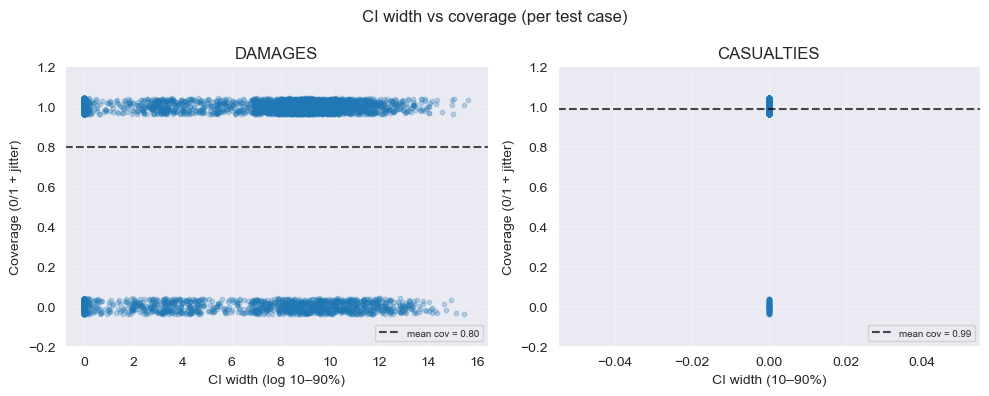

In [ ]:
# CI width vs coverage infographic (10–90% intervals)
# Uses Monte Carlo CIs from `all_samples` / `y_true_orig`.
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
rng = np.random.default_rng(0)

for ax, target_idx in zip(axes, [0, 1]):
    name = TARGET_COLS[target_idx]
    y_true = y_true_orig[:, target_idx]

    # 10–90% CI from MC samples
    q10 = np.percentile(all_samples[:, :, target_idx], 10, axis=1)
    q90 = np.percentile(all_samples[:, :, target_idx], 90, axis=1)

    # Width: log-scale for damages, raw for casualties (matches earlier plots)
    if target_idx == 0:
        width = np.log1p(q90) - np.log1p(q10)
        x_label = "CI width (log 10–90%)"
    else:
        width = q90 - q10
        x_label = "CI width (10–90%)"

    cover = ((y_true >= q10) & (y_true <= q90)).astype(float)
    jitter = (rng.random(len(width)) - 0.5) * 0.08

    ax.scatter(width, cover + jitter, alpha=0.25, s=10, c="C0")
    ax.axhline(cover.mean(), color="k", ls="--", alpha=0.7,
               label=f"mean cov = {cover.mean():.2f}")
    ax.set_xlabel(x_label)
    ax.set_ylabel("Coverage (0/1 + jitter)")
    ax.set_title(name)
    ax.set_ylim(-0.2, 1.2)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=7, loc="lower right")

plt.suptitle("CI width vs coverage (per test case)")
plt.tight_layout()
plt.show()

C:\Users\xPica\AppData\Local\Temp\ipykernel_21940\4068877341.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(widths_by_level, labels=labels, showfliers=False)


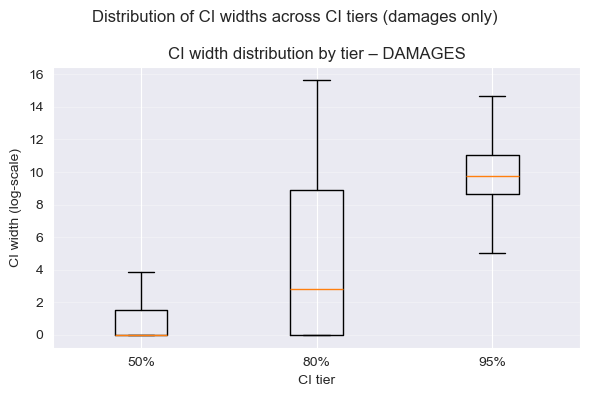

In [ ]:
# CI width distribution across CI tiers (damages only)

ci_levels = [0.50, 0.80, 0.95]

fig, ax = plt.subplots(figsize=(6, 4))

target_idx = 0  # damages only
name = TARGET_COLS[target_idx]

widths_by_level = []
labels = []

for level in ci_levels:
    lo = (1 - level) / 2 * 100
    hi = (1 + level) / 2 * 100

    q_lo = np.percentile(all_samples[:, :, target_idx], lo, axis=1)
    q_hi = np.percentile(all_samples[:, :, target_idx], hi, axis=1)

    # Log-width for damages
    widths = np.log1p(q_hi) - np.log1p(q_lo)

    widths_by_level.append(widths)
    labels.append(f"{int(level * 100)}%")

ax.boxplot(widths_by_level, labels=labels, showfliers=False)
ax.set_xlabel("CI tier")
ax.set_ylabel("CI width (log-scale)")
ax.set_title(f"CI width distribution by tier – {name}")
ax.grid(True, axis="y", alpha=0.3)

plt.suptitle("Distribution of CI widths across CI tiers (damages only)")
plt.tight_layout()
plt.show()

### Geographic CI Width Map (80% CI, log color scale)

Events colored by **80% CI width**; color is on a **logarithmic scale** (dark = narrow/confident, bright = wide/uncertain).

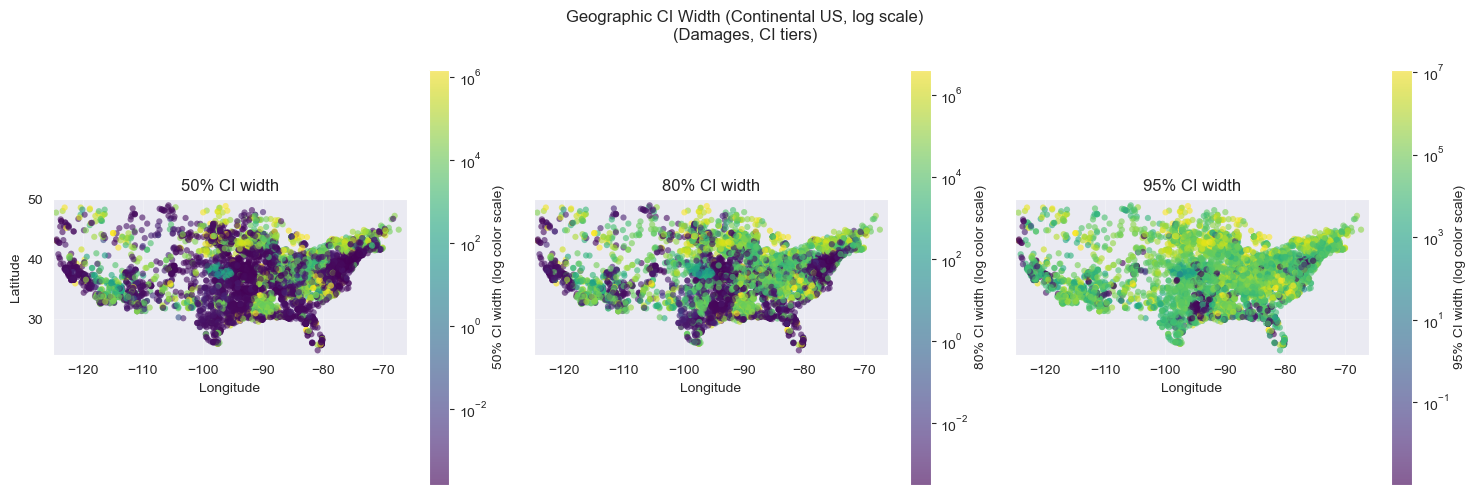

In [ ]:
# CI Width maps for various CI tiers (log color scale) – subplot for each ci_level

ci_levels = [0.50, 0.80, 0.95]
level_names = [f"{int(level*100)}%" for level in ci_levels]
target_idx = 0  # damages only, as in prompt

n_levels = len(ci_levels)
fig, axes = plt.subplots(1, n_levels, figsize=(5 * n_levels, 5), sharex=True, sharey=True)

if n_levels == 1:
    axes = [axes]  # in case of single level

for i, (level, name, ax) in enumerate(zip(ci_levels, level_names, axes)):
    lo = (1 - level) / 2 * 100
    hi = (1 + level) / 2 * 100

    q_lo = np.percentile(all_samples[:, :, target_idx], lo, axis=1)
    q_hi = np.percentile(all_samples[:, :, target_idx], hi, axis=1)
    ci_width = q_hi - q_lo  # on original scale

    ci_width_us = ci_width[mask_us]

    # Avoid zeros for log normalization
    positive = ci_width_us[ci_width_us > 0]
    if positive.size == 0:
        vmin = 1e-6
        vmax = 1.0
    else:
        vmin = np.percentile(positive, 1)
        vmax = np.percentile(positive, 99)
        if vmin <= 0:
            vmin = positive.min() * 0.5

    norm = mcolors.LogNorm(vmin=vmin, vmax=vmax)

    sc = ax.scatter(
        lons_us,
        lats_us,
        c=ci_width_us,
        cmap="viridis",
        norm=norm,
        alpha=0.6,
        s=20,
        edgecolors="none",
    )
    ax.set_xlim(LON_MIN, LON_MAX)
    ax.set_ylim(LAT_MIN, LAT_MAX)
    ax.set_xlabel("Longitude")
    if i == 0:
        ax.set_ylabel("Latitude")
    ax.set_title(f"{name} CI width")
    ax.set_aspect("equal")
    ax.grid(True, alpha=0.3)
    plt.colorbar(sc, ax=ax, label=f"{name} CI width (log color scale)")

plt.suptitle("Geographic CI Width (Continental US, log scale)\n(Damages, CI tiers)")
plt.tight_layout()
plt.show()